In [60]:
import pickle
import re

import dowhy.gcm as gcm
import matplotlib.pyplot as plt
import networkx as nx
import numpy.random as npr
import pandas as pd
import xmltodict
from dowhy.gcm import (
    InvertibleStructuralCausalModel, AdditiveNoiseModel,
    EmpiricalDistribution, ScipyDistribution
)
from dowhy.gcm.auto import AssignmentQuality, AutoAssignmentSummary
from dowhy.gcm.ml import create_polynom_regressor
from scipy import stats

from modeling.models import SumModel

npr.seed(42)

In [64]:
raw_data = pd.read_pickle('./data/rnd_proprio_spring-act_steps-1m_fskip-50.pkl')
raw_data.describe()

,act:right_shoulder_horizontal,act:right_shoulder_abduction,act:right_shoulder_internal,act:right_elbow,act:left_shoulder_horizontal,act:left_shoulder_abduction,act:left_shoulder_internal,act:left_elbow,act:right_wrist_rotation,act:right_wrist_flexion,...,joint:right_hand3.pos1,joint:right_fingers.pos1,joint:left_shoulder_horizontal.pos1,joint:left_shoulder_ad_ab.pos1,joint:left_shoulder_rotation.pos1,joint:left_elbow.pos1,joint:left_hand1.pos1,joint:left_hand2.pos1,joint:left_hand3.pos1,joint:left_fingers.pos1
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,-0.000184,0.155915,-0.179924,-0.085187,-0.000173,0.156570,-0.179798,-0.085677,0.000779,-0.215099,...,0.022377,-2.010945,0.426486,1.772557,-0.699270,-1.238793,-0.186478,-0.300353,0.011527,-1.771600
std,0.577551,0.487100,0.473389,0.528335,0.577327,0.486820,0.473683,0.528383,0.577129,0.453190,...,0.588522,0.881355,0.918126,1.176026,1.149747,1.117077,0.993590,0.739845,0.598157,0.837369
min,-1.000000,-0.687498,-1.000000,-0.999998,-1.000000,-0.687496,-0.999999,-0.999996,-1.000000,-1.000000,...,-1.103252,-2.899006,-0.785554,-0.262978,-1.968072,-2.753692,-1.811314,-1.803855,-1.063714,-2.818733
25%,-0.500577,-0.266645,-0.589720,-0.542596,-0.500496,-0.264583,-0.589728,-0.543592,-0.498757,-0.607557,...,-0.478204,-2.593364,-0.418574,0.571343,-1.729445,-2.441845,-1.055897,-0.866687,-0.499570,-2.338354
50%,-0.000719,0.155582,-0.180068,-0.085178,-0.000773,0.156822,-0.179973,-0.086477,0.001266,-0.214265,...,0.038187,-2.440676,0.028134,2.105879,-1.225640,-1.345759,-0.241324,-0.299654,0.024860,-2.109170
75%,0.500624,0.578065,0.229858,0.372619,0.499989,0.578715,0.230768,0.372045,0.500936,0.177509,...,0.558075,-1.853759,1.253610,2.839257,0.416350,0.088507,0.600781,0.230611,0.558386,-1.579967
max,0.999998,1.000000,0.639999,0.829998,0.999995,0.999992,0.639998,0.830000,0.999994,0.569999,...,1.029041,0.698868,2.289317,3.404181,1.352012,0.331744,1.783057,1.653860,1.007630,0.584663


In [65]:
data_nonzero = raw_data.loc[:, ~(raw_data == 0.0).all(axis=0)]

In [66]:
with open('../../MIMo/mimoEnv/assets/mimo/MIMo_meta.xml', 'rb') as f:
    motors = xmltodict.parse(f)['mujoco']['actuator']['motor']

actuators = [
    col
    for col in raw_data.columns
    if col.startswith('act:')
]

act_joints = {
    act: f'joint:{motor["@joint"].removeprefix("robot:")}'
    for motor in motors
    if (act := motor['@name']) in actuators
}
joints = list(act_joints.values())

act_dpos = [
    (act, f'{act_joints[act]}.dpos')
    for act in actuators
]
dpos_qpos1 = [
    (f'{joint}.dpos', f'{joint}.pos1')
    for joint in joints
]
qpos0_qpos1 = [
    (f'{joint}.pos0', f'{joint}.pos1')
    for joint in joints
]

In [67]:
limits = raw_data.describe().loc[['min', 'max'], [f'{joint}.pos1' for joint in joints]]
joint_limits = {
    joint: (limits.loc['min', joint], limits.loc['max', joint])
    for joint in limits.columns
}

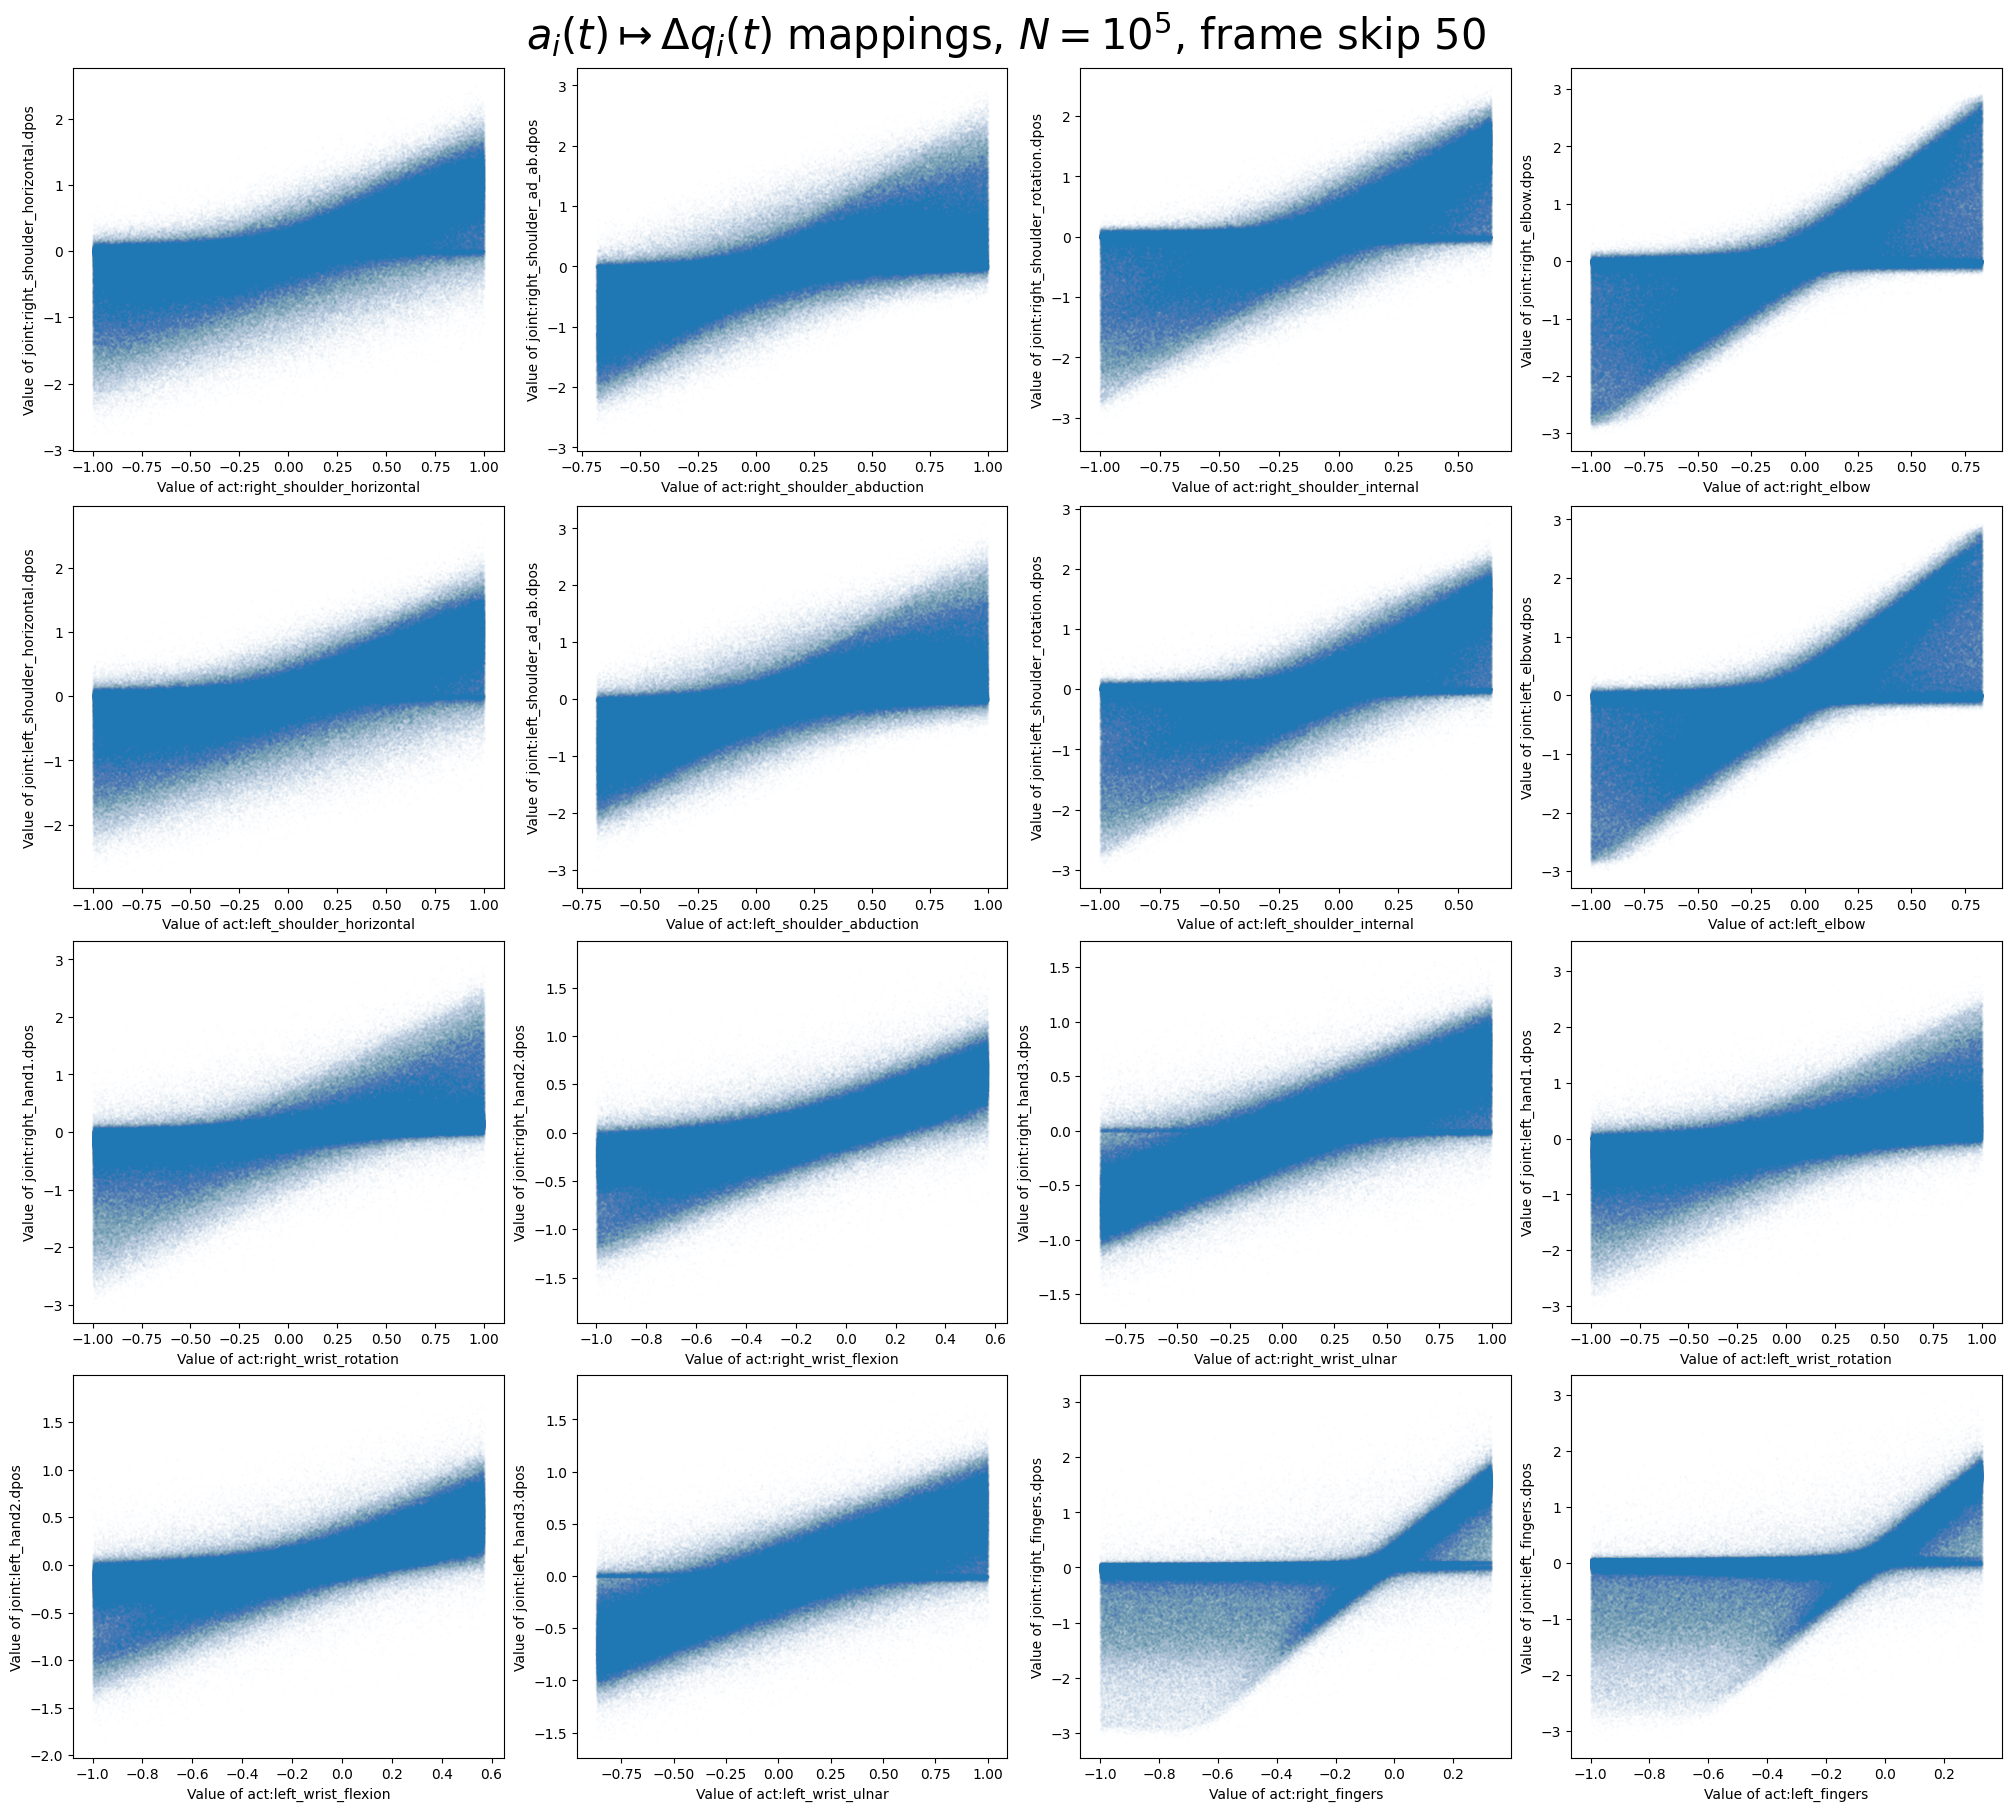

In [50]:
fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(20, 18), layout='constrained')

for idx, (act_name, dpos_name) in enumerate(act_dpos):
    act_data = data_nonzero.loc[:, act_name].to_numpy()
    dpos_data = data_nonzero.loc[:, dpos_name].to_numpy()

    ax: plt.Axes = axs[idx // 4, idx % 4]
    ax.scatter(act_data, dpos_data, s=1, alpha=0.01)
    ax.set_xlabel(f'Value of {act_name}')
    ax.set_ylabel(f'Value of {dpos_name}')

fig.suptitle(r'$a_i(t) \mapsto \Delta q_i(t)$ mappings, $N = 10^5$, frame skip 50', fontsize=30)
plt.show()
# plt.savefig('./data/act-dpos_rels_steps-1m_fskip-50.png', dpi=300)

In [52]:
proprio_G = nx.DiGraph([
    *act_dpos,
    *dpos_qpos1,
    *qpos0_qpos1
])

In [54]:
proprio_M = InvertibleStructuralCausalModel(proprio_G)

for joint in joints:
    j_name = f'{joint}.pos1'
    proprio_M.set_causal_mechanism(
        target_node=j_name,
        mechanism=AdditiveNoiseModel(
            prediction_model=SumModel(limits=joint_limits[j_name]),
            noise_model=ScipyDistribution(stats.uniform, loc=0, scale=0)
        )
    )

In [55]:
proprio_summary = gcm.auto.assign_causal_mechanisms(
    causal_model=proprio_M,
    based_on=data_nonzero,
    quality=AssignmentQuality.BETTER
)

In [56]:
print(proprio_summary)

When using this auto assignment function, the given data is used to automatically assign a causal mechanism to each node. Note that causal mechanisms can also be customized and assigned manually.
The following types of causal mechanisms are considered for the automatic selection:

If root node:
An empirical distribution, i.e., the distribution is represented by randomly sampling from the provided data. This provides a flexible and non-parametric way to model the marginal distribution and is valid for all types of data modalities.

If non-root node and the data is continuous:
Additive Noise Models (ANM) of the form X_i = f(PA_i) + N_i, where PA_i are the parents of X_i and the unobserved noise N_i is assumed to be independent of PA_i.To select the best model for f, different regression models are evaluated and the model with the smallest mean squared error is selected.Note that minimizing the mean squared error here is equivalent to selecting the best choice of an ANM.

If non-root node

In [57]:
def process_summary(summary: str | AutoAssignmentSummary) -> dict[str, float]:
    if isinstance(summary, AutoAssignmentSummary):
        summary = str(summary)

    N = 0
    ranking: dict[str, float] = {}

    for node in summary.split('\n\n'):
        node = re.sub(r'\n +', ' ', node)
        mechanisms = [
            mech.strip().split(': ')[0]
            for mech in re.findall(
                r'\n.+: -?(?:0|[1-9]\d*)(?:\.\d+)?(?:[eE][+\-]?\d+)?',
                node
            )
        ]

        if not mechanisms:
            continue

        N += 1

        for idx, mech in enumerate(mechanisms):
            if mech not in ranking:
                ranking[mech] = 0

            ranking[mech] += idx + 1

    for mech in ranking:
        ranking[mech] /= N

    ranking = dict(sorted(ranking.items(), key=lambda item: item[1]))
    return ranking


In [58]:
process_summary(proprio_summary)

{"Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(include_bias=False)), ('linearregression', LinearRegression)])": 1.125,
 'HistGradientBoostingRegressor': 3.0,
 'LassoCV(max_iter=10000)': 3.9375,
 'RidgeCV': 4.0625,
 'LinearRegression': 4.1875,
 'SVR': 5.1875,
 'AdaBoostRegressor': 7.3125,
 'KNeighborsRegressor': 7.4375,
 'RandomForestRegressor': 8.875,
 'ExtraTreesRegressor': 9.875}

In [68]:
full_G = nx.DiGraph([
    *act_dpos,
    *dpos_qpos1,
    *qpos0_qpos1
])
full_M = InvertibleStructuralCausalModel(full_G)

for act in actuators:
    full_M.set_causal_mechanism(
        target_node=act,
        mechanism=EmpiricalDistribution()
    )

for joint in joints:
    full_M.set_causal_mechanism(
        target_node=f'{joint}.pos0',
        mechanism=EmpiricalDistribution()
    )

    full_M.set_causal_mechanism(
        target_node=f'{joint}.dpos',
        mechanism=AdditiveNoiseModel(create_polynom_regressor(degree=2))
    )

    full_M.set_causal_mechanism(
        target_node=f'{joint}.pos1',
        mechanism=AdditiveNoiseModel(
            prediction_model=SumModel(limits=joint_limits[f'{joint}.pos1']),
            noise_model=ScipyDistribution(stats.uniform, loc=0, scale=0)
        )
    )

In [69]:
assert set(data_nonzero.columns) == set(full_G.nodes)

In [73]:
gcm.fit(
    causal_model=full_M,
    data=data_nonzero,
    return_evaluation_summary=False
)

Fitting causal mechanism of node joint:left_fingers.pos0: 100%|██████████| 64/64 [00:01<00:00, 36.37it/s]             


In [74]:
with open('./models/proprio-cbn_N=1m_fskip=50.pkl', 'wb') as f:
    pickle.dump(full_M, f)